In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Force TensorFlow to only allocate memory as needed
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU Memory Growth Enabled Successfully!")
    except RuntimeError as e:
        print(f"Memory growth error: {e}")

2026-05-26 09:00:33.873643: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-26 09:00:34.399861: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-26 09:00:50.858048: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU Memory Growth Enabled Successfully!


# Hyperparameter
---


In [2]:
# -- DATA AUGMENTATION --
# Set how many augmented variations you want per image
NUM_AUGMENTATIONS_PER_IMAGE = 6

links:
- https://www.geeksforgeeks.org/python/python-loop-through-folders-and-files-in-directory/

notes:
- to handle class imbalance (750/250) tell the loss function to care more about the minority class.
-

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rhythmghai/ai-vs-real-images-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/tobias/.cache/kagglehub/datasets/rhythmghai/ai-vs-real-images-dataset/versions/1


## Import packages
---


In [4]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, Activation, GlobalAveragePooling2D
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

### Load real images
---


In [5]:
path = kagglehub.dataset_download("rhythmghai/ai-vs-real-images-dataset")
dir = path + "/real_dataset/"

valid_extensions = (".jpg", ".jpeg", ".png")

# collect all sub-folder paths
sub_folder_paths = []

for root, dirs, files in os.walk(dir):
    for filename in files:
        if filename.lower().endswith(valid_extensions):
            sub_folder_paths.append(os.path.join(root, filename)) # append full path

images_real = [] # numpy Array (from cv2)
for path in sub_folder_paths:
    img = cv2.imread(path)

    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images_real.append(img)

print(f'loaded {len(images_real)} images')


loaded 745 images


### Load Ai generated images
---


In [6]:
path = kagglehub.dataset_download("rhythmghai/ai-vs-real-images-dataset")
dir = path + "/Ai_generated_dataset/"
print(path)
print(dir)

valid_extensions = (".jpg", ".jpeg", ".png")

# collect all sub-folder paths
sub_folder_paths = []

for root, dirs, files in os.walk(dir):
    for filename in files:
        if filename.lower().endswith(valid_extensions):
            sub_folder_paths.append(os.path.join(root, filename)) # append full path

images_ai = []
for path in sub_folder_paths:
    img = cv2.imread(path)

    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images_ai.append(img)

print(f'loaded {len(images_ai)} images')

/home/tobias/.cache/kagglehub/datasets/rhythmghai/ai-vs-real-images-dataset/versions/1
/home/tobias/.cache/kagglehub/datasets/rhythmghai/ai-vs-real-images-dataset/versions/1/Ai_generated_dataset/
loaded 250 images


# Standardize Image Sizes
----


In [7]:
IMG_SIZE = (224,224)

processed_real = [cv2.resize(img, IMG_SIZE) for img in images_real]
processed_ai = [cv2.resize(img, IMG_SIZE) for img in images_ai]

X_real = np.array(processed_real)
X_ai = np.array(processed_ai)

y_real = np.zeros(len(X_real), dtype=np.int32)  # class 0
y_ai = np.ones(len(X_ai), dtype=np.int32)       # class 1

X_combined = np.concatenate([X_real, X_ai], axis=0)
y_combined = np.concatenate([y_real, y_ai], axis=0)

# Train, Test Split
---


In [8]:
# Split 80/20 for training/(validation/test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_combined, y_combined,
    test_size=0.2,
    stratify=y_combined,
    random_state=42
)

# Split 50/50 for validation/test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

# Data Augmentation
---


In [9]:
import numpy as np

# Define the transformations
augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(height_factor=0.08, width_factor=0.08),
    tf.keras.layers.RandomContrast(0.15),
])

augmented_images = []
augmented_labels = []

print(f"Original training samples: {len(X_train)}")
print("Generating extra samples...")

# Loop through training data to create fresh samples
for img, label in zip(X_train, y_train):
    # Keep the original image
    augmented_images.append(img)
    augmented_labels.append(label)

    # Generate the extra variations
    for _ in range(NUM_AUGMENTATIONS_PER_IMAGE):
        # add a batch dimension [1, H, W, C] for Keras layers, then squeeze it back to [H, W, C]
        aug_img = augmenter(np.expand_dims(img, axis=0), training=True)
        augmented_images.append(np.squeeze(aug_img, axis=0))
        augmented_labels.append(label)

# Convert back to numpy arrays
X_train_expanded = np.array(augmented_images)
y_train_expanded = np.array(augmented_labels)

print(f"Expanded training samples: {len(X_train_expanded)}")

I0000 00:00:1779778902.081538     580 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0


Original training samples: 796
Generating extra samples...


E0000 00:00:1779778902.458794     711 ptx_compiler_helpers.cc:88] *** WARNING *** Invoking ptxas with version 12.0.140, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.
2026-05-26 09:01:42.461659: W external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:237] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 12.0
2026-05-26 09:01:42.461686: W external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:240] Used ptxas at /usr/bin/ptxas
2026-05-26 09:01:42.461724: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:188] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-05-26 09:01:42.462617: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:188] Failed to compile generated PTX with ptxas. Falling back to com

Expanded training samples: 5572


# Build Tensorflow dataset
---


In [10]:
BUFFER_SIZE = len(X_combined)
SPLIT = 0.8
BATCH_SIZE = 32

train_ds = (tf.data.Dataset.from_tensor_slices((X_train_expanded, y_train_expanded))
            .shuffle(BUFFER_SIZE)
            .batch(BATCH_SIZE)
            .prefetch(buffer_size=tf.data.AUTOTUNE))

test_ds = ((tf.data.Dataset.from_tensor_slices((X_test, y_test)))
           .batch(BATCH_SIZE)
           .prefetch(buffer_size=tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
          .batch(BATCH_SIZE)
          .prefetch(buffer_size=tf.data.AUTOTUNE))

# Build Tensorflow CNN
---


In [11]:
model = Sequential([
    
    # ————————————————————————————————————————————————————————————————
    # BLOCK 1: 128x128x3 -> 64x64x32
    # ————————————————————————————————————————————————————————————————
    Conv2D(32, (3, 3), padding='same', name='block1_conv1'),
    BatchNormalization(name='block1_bn1'),
    Activation('relu', name='block1_relu1'),

    Conv2D(32, (3, 3), padding='same', name='block1_conv2'),
    BatchNormalization(name='block1_bn2'),
    Activation('relu', name='block1_relu2'),

    MaxPooling2D((2, 2), name='block1_pool'),
    Dropout(0.5, name='block1_drop'), # Adjust dropout rate as needed

    # ————————————————————————————————————————————————————————————————
    # BLOCK 2: 64x64x32 -> 32x32x64
    # ————————————————————————————————————————————————————————————————
    Conv2D(64, (3, 3), padding='same', name='block2_conv1'),
    BatchNormalization(name='block2_bn1'),
    Activation('relu', name='block2_relu1'),

    Conv2D(64, (3, 3), padding='same', name='block2_conv2'),
    BatchNormalization(name='block2_bn2'),
    Activation('relu', name='block2_relu2'),

    MaxPooling2D((2, 2), name='block2_pool'),
    Dropout(0.5, name='block2_drop'),

    # ————————————————————————————————————————————————————————————————
    # BLOCK 3: 32x32x64 -> 16x16x128
    # ————————————————————————————————————————————————————————————————
    Conv2D(128, (3, 3), padding='same', name='block3_conv1'),
    BatchNormalization(name='block3_bn1'),
    Activation('relu', name='block3_relu1'),

    Conv2D(128, (3, 3), padding='same', name='block3_conv2'),
    BatchNormalization(name='block3_bn2'),
    Activation('relu', name='block3_relu2'),

    MaxPooling2D((2, 2), name='block3_pool'),
    Dropout(0.5, name='block3_drop'),

    # ————————————————————————————————————————————————————————————————
    # BLOCK 4: 16x16x128 -> 8x8x256
    # —————————————————————————————————────────────────———————————————
    Conv2D(256, (3, 3), padding='same', name='block4_conv1'),
    BatchNormalization(name='block4_bn1'),
    Activation('relu', name='block4_relu1'),

    Conv2D(256, (3, 3), padding='same', name='block4_conv2'),
    BatchNormalization(name='block4_bn2'),
    Activation('relu', name='block4_relu2'),

    MaxPooling2D((2, 2), name='block4_pool'),
    Dropout(0.5, name='block4_drop'),

    # ————————————————————————————————————————————————————————————————
    # BLOCK 5: 8x8x256 -> 4x4x512
    # ————————————————————————————————————————————————————————————————
    Conv2D(512, (3, 3), padding='same', name='block5_conv1'),
    BatchNormalization(name='block5_bn1'),
    Activation('relu', name='block5_relu1'),

    Conv2D(512, (3, 3), padding='same', name='block5_conv2'),
    BatchNormalization(name='block5_bn2'),
    Activation('relu', name='block5_relu2'),

    MaxPooling2D((2, 2), name='block5_pool'),
    Dropout(0.5, name='block5_drop'),

    # ————————————————————————————————————————————————————————————————
    # HEAD: Classification Layers
    # ————————————————————————————————————————————————————————————————
    GlobalAveragePooling2D(name='gap'),

    Dense(512, name='fc1'),
    BatchNormalization(name='fc1_bn'),
    Activation('relu', name='fc1_relu'),
    Dropout(0.5, name='fc1_drop'),

    Dense(256, name='fc2'),
    BatchNormalization(name='fc2_bn'),
    Activation('relu', name='fc2_relu'),
    Dropout(0.5, name='fc2_drop'),

    # Binary output (0 or 1)
    Dense(1, activation='sigmoid', name='output')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
    jit_compile=False
)

# Train the Model
---


In [20]:
# Compute class weights to handle class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_combined),
    y=y_train_expanded
)

class_weight_dict = dict(enumerate(class_weights))

es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

for i in range(5):
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        class_weight=class_weight_dict,
        callbacks=[es],
        verbose=1
    )
print(history)

Epoch 1/15


/mnt/c/Users/Tobia/Documents/FH_Technikum_Wien/Fh Technikum repos/SS26/CV&NLP/projekt/CV/.venv-ubuntu/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


175/175 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - accuracy: 0.8846 - loss: 0.2563 - val_accuracy: 0.7677 - val_loss: 0.3918
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step - accuracy: 0.8929 - loss: 0.2211 - val_accuracy: 0.9091 - val_loss: 0.2646
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - accuracy: 0.8864 - loss: 0.2447 - val_accuracy: 0.8586 - val_loss: 0.3103
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step - accuracy: 0.9087 - loss: 0.2078 - val_accuracy: 0.9091 - val_loss: 0.3580
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step - accuracy: 0.8979 - loss: 0.2179 - val_accuracy: 0.8081 - val_loss: 0.4576
Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step - accuracy: 0.9130 - loss: 0.2025 - val_accuracy: 0.7677 - val_loss: 0.4884
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - accuracy: 0.9051 - loss: 0.2061 - val_accuracy: 0.8283 - val_loss: 0.4575
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step - accuracy: 0.9205 - loss: 0.1869 - val_accurac

# Test Data with val_ds
---

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
              precision    recall  f1-score   support

    Real (0)       0.93      0.99      0.95        75
      AI (1)       0.95      0.76      0.84        25

    accuracy                           0.93       100
   macro avg       0.94      0.87      0.90       100
weighted avg       0.93      0.93      0.93       100



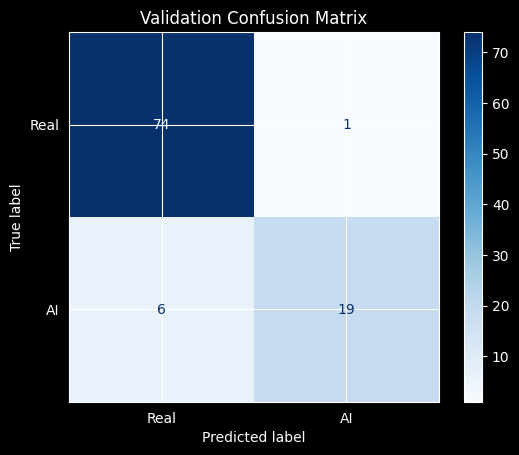

In [21]:
import numpy as np

y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

y_pred_probs = model.predict(test_ds)

# 3. Convert probabilities to binary choices (0 or 1)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()

from sklearn.metrics import classification_report

# Print precision, recall, and F1-score
print(classification_report(y_true, y_pred, target_names=['Real (0)', 'AI (1)']))

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'AI'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Validation Confusion Matrix")
plt.show()

# Save model to disk
---


In [14]:
# save model to disk
model.save("my_model.keras")

PermissionError: [Errno 13] Permission denied: 'my_model.keras'

# Load model from disk
---


In [ ]:
model = tf.keras.models.load_model("my_model.keras")

# Visualize some pictures of each class with its classification
---

In [ ]:
# Visualize sample predictions from each class
import matplotlib.pyplot as plt
import random

# Get samples from validation set
real_samples = []
ai_samples = []

for images, labels in test_ds:
    for img, label in zip(images.numpy(), labels.numpy()):
        if label == 0 and len(real_samples) < 4:
            real_samples.append(img)
        elif label == 1 and len(ai_samples) < 4:
            ai_samples.append(img)
        if len(real_samples) == 4 and len(ai_samples) == 4:
            break
    if len(real_samples) == 4 and len(ai_samples) == 4:
        break

# Combine samples
all_samples = real_samples + ai_samples
all_labels = [0]*len(real_samples) + [1]*len(ai_samples)

# Get predictions
predictions = model.predict(np.array(all_samples))
predicted_classes = (predictions >= 0.5).astype(int).flatten()

# Plot
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (img, true_label, pred_class, pred_prob) in enumerate(zip(all_samples, all_labels, predicted_classes, predictions)):
    axes[idx].imshow(img.astype('uint8'))
    
    true_class_name = "Real" if true_label == 0 else "AI"
    pred_class_name = "Real" if pred_class == 0 else "AI"
    
    # Color: green if correct, red if wrong
    color = 'green' if true_label == pred_class else 'red'
    
    title = f"True: {true_class_name}\nPredicted: {pred_class_name} ({pred_prob[0]:.2%})"
    axes[idx].set_title(title, color=color, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Sample Predictions: Real vs AI Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()